# <center>Практика:методы классификации


In [93]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

**Функция для формирования csv-файла посылки на Kaggle:**

In [94]:
def write_to_submission_file(predicted_labels, out_file, train_num=891,
                    target='SatisfactionScore', index_label="PassengerId"):
    # turn predictions into data frame and save as csv file
    predicted_df = pd.DataFrame(predicted_labels,
                                index = np.arange(train_num + 1,
                                                  train_num + 1 +
                                                  predicted_labels.shape[0]),
                                columns=[target])
    predicted_df.to_csv(out_file, index_label=index_label)

**Считываем обучающую и тестовую выборки.**

In [95]:
import pandas as pd

train_df = pd.read_csv("store_train.csv")
test_df = pd.read_csv("store_test.csv")


In [96]:
y = train_df['SatisfactionScore']

In [97]:
train_df.head()

,CustomerID,Gender,Age,Region,ProductCategory,PurchaseAmount,LoyaltyLevel,PaymentMethod,Returned,SatisfactionScore,Extra_0,Extra_1
0,CUST1000,Male,24,West,Sports,712.09,Gold,Online,0,8,1.776087,0.826249
1,CUST1001,Female,42,East,Clothing,935.67,Platinum,Online,0,2,-0.460775,0.085957
2,CUST1002,Male,62,East,Home,707.27,Gold,Cash,0,5,-0.769562,-0.587154
3,CUST1003,Male,21,North,Electronics,673.96,Gold,Card,1,9,0.547303,-0.532172
4,CUST1004,Male,53,Central,Home,714.06,Platinum,Card,0,8,1.364082,0.385473


In [98]:
train_df.describe(include='all')

,CustomerID,Gender,Age,Region,ProductCategory,PurchaseAmount,LoyaltyLevel,PaymentMethod,Returned,SatisfactionScore,Extra_0,Extra_1
count,891,891,891.000000,891,891,891.000000,891,891,891.000000,891.000000,891.000000,891.000000
unique,891,2,NaN,5,6,NaN,4,3,NaN,NaN,NaN,NaN
top,CUST1890,Female,NaN,South,Home,NaN,Gold,Online,NaN,NaN,NaN,NaN
freq,1,453,NaN,190,173,NaN,232,313,NaN,NaN,NaN,NaN
mean,NaN,NaN,43.641975,NaN,NaN,770.432009,NaN,NaN,0.080808,5.523008,-0.046875,-0.028249
std,NaN,NaN,15.095307,NaN,NaN,429.765856,NaN,NaN,0.272693,2.872238,0.998058,1.062787
min,NaN,NaN,18.000000,NaN,NaN,5.660000,NaN,NaN,0.000000,1.000000,-3.582063,-3.538858
25%,NaN,NaN,30.000000,NaN,NaN,403.300000,NaN,NaN,0.000000,3.000000,-0.693088,-0.751870
50%,NaN,NaN,44.000000,NaN,NaN,795.220000,NaN,NaN,0.000000,5.000000,-0.056940,-0.021345
75%,NaN,NaN,56.000000,NaN,NaN,1143.440000,NaN,NaN,0.000000,8.000000,0.611183,0.672277


In [99]:
test_df.describe(include='all')

,CustomerID,Gender,Age,Region,ProductCategory,PurchaseAmount,LoyaltyLevel,PaymentMethod,Returned,SatisfactionScore,Extra_0,Extra_1
count,418,418,418.000000,418,418,418.000000,418,418,418.000000,418.000000,418.000000,418.000000
unique,418,2,NaN,5,6,NaN,4,3,NaN,NaN,NaN,NaN
top,CUST1417,Female,NaN,North,Electronics,NaN,Silver,Card,NaN,NaN,NaN,NaN
freq,1,212,NaN,88,77,NaN,117,147,NaN,NaN,NaN,NaN
mean,NaN,NaN,44.672249,NaN,NaN,767.311077,NaN,NaN,0.086124,5.411483,-0.040548,-0.006375
std,NaN,NaN,14.722379,NaN,NaN,436.264006,NaN,NaN,0.280884,2.839945,0.989518,0.961175
min,NaN,NaN,18.000000,NaN,NaN,12.390000,NaN,NaN,0.000000,1.000000,-3.471430,-3.324756
25%,NaN,NaN,33.000000,NaN,NaN,368.750000,NaN,NaN,0.000000,3.000000,-0.708474,-0.681653
50%,NaN,NaN,45.000000,NaN,NaN,787.015000,NaN,NaN,0.000000,5.000000,0.015070,-0.011639
75%,NaN,NaN,56.750000,NaN,NaN,1138.592500,NaN,NaN,0.000000,8.000000,0.639293,0.691080


**Заполним пропуски медианными значениями.**

In [100]:
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(train_df['Age'].median(), inplace=True)
train_df['Region'].fillna('S', inplace=True)
test_df['PurchaseAmount'].fillna(train_df['PurchaseAmount'].median(), inplace=True)

/tmp/ipython-input-2062001507.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
/tmp/ipython-input-2062001507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

**Кодируем категориальные признаки `Pclass`, `Sex`, `SibSp`, `Parch` и `Embarked` с помощью техники One-Hot-Encoding.**

In [101]:

train_df = pd.concat([
    train_df,
    pd.get_dummies(train_df['LoyaltyLevel'], prefix="Loyalty"),
    pd.get_dummies(train_df['Gender'], prefix="Gender"),
    pd.get_dummies(train_df['Region'], prefix="Region"),
    pd.get_dummies(train_df['ProductCategory'], prefix="ProductCategory"),
    pd.get_dummies(train_df['PaymentMethod'], prefix="PaymentMethod")
], axis=1)

test_df = pd.concat([
    test_df,
    pd.get_dummies(test_df['LoyaltyLevel'], prefix="Loyalty"),
    pd.get_dummies(test_df['Gender'], prefix="Gender"),
    pd.get_dummies(test_df['Region'], prefix="Region"),
    pd.get_dummies(test_df['ProductCategory'], prefix="ProductCategory"),
    pd.get_dummies(test_df['PaymentMethod'], prefix="PaymentMethod")
], axis=1)


In [102]:
train_df.drop([
    'SatisfactionScore',   # целевая переменная
    'LoyaltyLevel',        # категориальное, уже закодировано
    'CustomerID',          # идентификатор клиента
    'Gender',              # уже закодировано
    'PaymentMethod',       # уже закодировано
    'ProductCategory',     # уже закодировано
    'Region'               # уже закодировано
], axis=1, inplace=True)

test_df.drop([
    'LoyaltyLevel',
    'CustomerID',
    'Gender',
    'PaymentMethod',
    'ProductCategory',
    'Region'
], axis=1, inplace=True)

**В тестовой выборке появляется новое значение Parch = 9, которого нет в обучающей выборке. Проигнорируем его.**

In [103]:
train_df.shape, test_df.shape

((891, 25), (418, 26))

In [104]:
set(test_df.columns) - set(train_df.columns)

{'SatisfactionScore'}

In [105]:
test_df.drop(['Parch_9'], axis=1, inplace=True, errors='ignore')

In [106]:
train_df.head()

,Age,PurchaseAmount,Returned,Extra_0,Extra_1,Loyalty_Bronze,Loyalty_Gold,Loyalty_Platinum,Loyalty_Silver,Gender_Female,...,Region_West,ProductCategory_Beauty,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,ProductCategory_Home,ProductCategory_Sports,PaymentMethod_Card,PaymentMethod_Cash,PaymentMethod_Online
0,24,712.09,0,1.776087,0.826249,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,True
1,42,935.67,0,-0.460775,0.085957,False,False,True,False,True,...,False,False,True,False,False,False,False,False,False,True
2,62,707.27,0,-0.769562,-0.587154,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,21,673.96,1,0.547303,-0.532172,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,53,714.06,0,1.364082,0.385473,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False


In [107]:
test_df.head()

,Age,PurchaseAmount,Returned,SatisfactionScore,Extra_0,Extra_1,Loyalty_Bronze,Loyalty_Gold,Loyalty_Platinum,Loyalty_Silver,...,Region_West,ProductCategory_Beauty,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Groceries,ProductCategory_Home,ProductCategory_Sports,PaymentMethod_Card,PaymentMethod_Cash,PaymentMethod_Online
0,63,913.57,0,10,-0.262979,0.191539,False,False,False,True,...,True,False,False,True,False,False,False,False,False,True
1,35,771.47,0,5,-1.835711,-0.559742,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
2,19,349.85,0,10,0.330065,-0.193949,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
3,52,268.91,0,5,0.619926,-0.663304,False,False,True,False,...,True,False,False,False,False,False,True,True,False,False
4,33,334.63,0,3,-1.089080,-0.294779,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False


## 1. Дерево решений без настройки параметров

**Обучите на имеющейся выборке дерево решений (`DecisionTreeClassifier`) максимальной глубины 2. Используйте параметр `random_state=17` для воспроизводимости результатов.**

In [108]:
tree = DecisionTreeClassifier(max_depth=2, random_state=17)

tree.fit(train_df, y)

DecisionTreeClassifier(max_depth=2, random_state=17)

**Сделайте с помощью полученной модели прогноз для тестовой выборки **

In [109]:
def align_features(train_features, test_features):
    """
    Выравнивает признаки в train и test наборах
    """

    common_features = list(set(train_features.columns) & set(test_features.columns))


    test_aligned = test_features[common_features]


    missing_features = list(set(train_features.columns) - set(test_features.columns))
    for feature in missing_features:
        test_aligned[feature] = 0


    test_aligned = test_aligned[train_features.columns]

    return test_aligned


test_df_aligned = align_features(train_df, test_df)


predictions = tree.predict(test_df_aligned)

**Сформируйте файл посылки и отправьте на Kaggle**

In [110]:
write_to_submission_file(predictions,
                         'store_tree_depth2.csv')

**У такой посылки результат на публичной тестовой выборке - 0.74641.**

In [111]:
export_graphviz(tree, out_file="../../store_tree_depth2.dot",
                feature_names=train_df.columns)
!dot -Tpng ../../store_tree_depth2.dot -o ../../store_tree_depth2.png

<img src='../../img/titanic_tree_depth2.png'>

## 2. Дерево решений с настройкой параметров

**Обучите на имеющейся выборке дерево решений (`DecisionTreeClassifier`). Также укажите `random_state=17`. Максимальную глубину и минимальное число элементов в листе настройте на 5-кратной кросс-валидации с помощью `GridSearchCV`.**

In [112]:
# tree params for grid search
tree_params = {'max_depth': list(range(1, 5)),
               'min_samples_leaf': list(range(1, 5))}

locally_best_tree = GridSearchCV(DecisionTreeClassifier(random_state=17),
                                 tree_params,
                                 verbose=True, n_jobs=-1, cv=5)
locally_best_tree.fit(train_df, y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=17), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4],
                         'min_samples_leaf': [1, 2, 3, 4]},
             verbose=True)

In [113]:
export_graphviz(locally_best_tree.best_estimator_,
                out_file="../../store_tree_tuned.dot",
                feature_names=train_df.columns)
!dot -Tpng ../../store_tree_tuned.dot -o ../../store_tree_tuned.png

<img src='../../img/titanic_tree_tuned.png'>

In [114]:
print("Best params:", locally_best_tree.best_params_)
print("Best cross validaton score", locally_best_tree.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 1}
Best cross validaton score 0.10664113991588726


**Сделайте с помощью полученной модели прогноз для тестовой выборки.**

In [115]:
def prepare_test_data(train_data, test_data):
    """
    Подготавливает test данные к тому же формату, что и train
    """
    test_prepared = test_data.copy()

    # Удаляем лишние столбцы, которых нет в train
    extra_columns = set(test_prepared.columns) - set(train_data.columns)
    if extra_columns:
        print(f"Удаляем лишние столбцы из test: {extra_columns}")
        test_prepared = test_prepared.drop(columns=list(extra_columns))

    # Добавляем недостающие столбцы (которые есть в train, но нет в test)
    missing_columns = set(train_data.columns) - set(test_prepared.columns)
    if missing_columns:
        print(f"Добавляем недостающие столбцы в test: {missing_columns}")
        for col in missing_columns:
            # Заполняем медианным значением из train или 0
            if col in train_data.select_dtypes(include=[np.number]).columns:
                test_prepared[col] = train_data[col].median()
            else:
                test_prepared[col] = 0

    # Упорядочиваем столбцы как в train
    test_prepared = test_prepared[train_data.columns]

    return test_prepared


test_df_prepared = prepare_test_data(train_df, test_df)

# 3. Проверяем, что признаки совпадают
print("Train features:", len(train_df.columns))
print("Test features:", len(test_df_prepared.columns))
print("Features match:", all(train_df.columns == test_df_prepared.columns))

# 4. Теперь делаем предсказание
predictions = locally_best_tree.predict(test_df_prepared)
print("Predictions shape:", predictions.shape)
print("First 10 predictions:", predictions[:10])

Удаляем лишние столбцы из test: {'SatisfactionScore'}
Train features: 25
Test features: 25
Features match: True
Predictions shape: (418,)
First 10 predictions: [4 6 7 7 7 7 2 7 7 2]


Train shape: (891, 12)
Test shape:  (418, 12)


,CustomerID,Gender,Age,Region,ProductCategory,PurchaseAmount,LoyaltyLevel,PaymentMethod,Returned,SatisfactionScore,Extra_0,Extra_1
0,CUST1000,Male,24,West,Sports,712.09,Gold,Online,0,8,1.776087,0.826249
1,CUST1001,Female,42,East,Clothing,935.67,Platinum,Online,0,2,-0.460775,0.085957
2,CUST1002,Male,62,East,Home,707.27,Gold,Cash,0,5,-0.769562,-0.587154
3,CUST1003,Male,21,North,Electronics,673.96,Gold,Card,1,9,0.547303,-0.532172
4,CUST1004,Male,53,Central,Home,714.06,Platinum,Card,0,8,1.364082,0.385473


,CustomerID,Gender,Age,Region,ProductCategory,PurchaseAmount,LoyaltyLevel,PaymentMethod,Returned,SatisfactionScore,Extra_0,Extra_1
0,CUST1000,Male,63,West,Electronics,913.57,Silver,Online,0,10,-0.262979,0.191539
1,CUST1001,Female,35,East,Beauty,771.47,Silver,Card,0,5,-1.835711,-0.559742
2,CUST1002,Male,19,East,Groceries,349.85,Silver,Online,0,10,0.330065,-0.193949
3,CUST1003,Male,52,West,Sports,268.91,Platinum,Card,0,5,0.619926,-0.663304
4,CUST1004,Male,33,North,Electronics,334.63,Gold,Card,0,3,-1.089080,-0.294779



--- dtypes и пропуски в train ---


,0
CustomerID,object
Gender,object
Age,int64
Region,object
ProductCategory,object
PurchaseAmount,float64
LoyaltyLevel,object
PaymentMethod,object
Returned,int64
SatisfactionScore,int64


,0
CustomerID,0
Gender,0
Age,0
Region,0
ProductCategory,0
PurchaseAmount,0
LoyaltyLevel,0
PaymentMethod,0
Returned,0
SatisfactionScore,0


Categorical: ['Gender', 'Region', 'ProductCategory', 'LoyaltyLevel', 'PaymentMethod']
Numerical: ['Age', 'PurchaseAmount', 'SatisfactionScore', 'Extra_0', 'Extra_1']

Processed shapes: (891, 20) (418, 20)


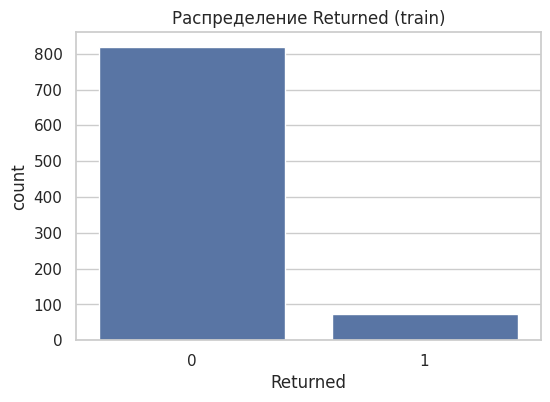


--- Decision Tree (baseline) metrics on test ---
Accuracy:  0.9114832535885168
Precision: 0.0
Recall:    0.0
F1:        0.0
ROC AUC:   0.532977021524142

Classification report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       382
           1       0.00      0.00      0.00        36

    accuracy                           0.91       418
   macro avg       0.46      0.50      0.48       418
weighted avg       0.83      0.91      0.87       418



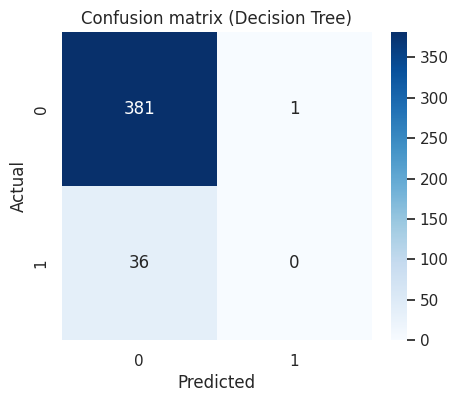

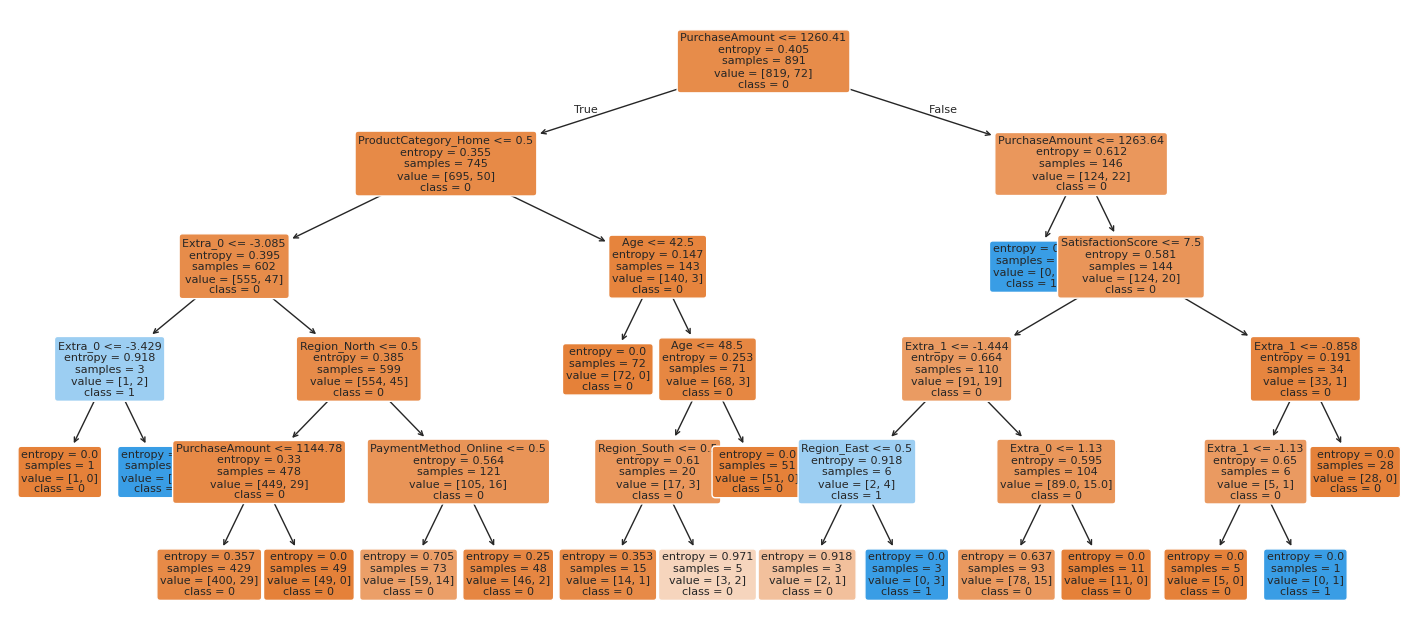


Top 20 feature importances (Decision Tree):


,0
PurchaseAmount,0.240196
Extra_1,0.168182
Extra_0,0.140814
Age,0.122190
ProductCategory_Home,0.076425
PaymentMethod_Online,0.065379
Region_North,0.062431
SatisfactionScore,0.057860
Region_East,0.038207
Region_South,0.028316


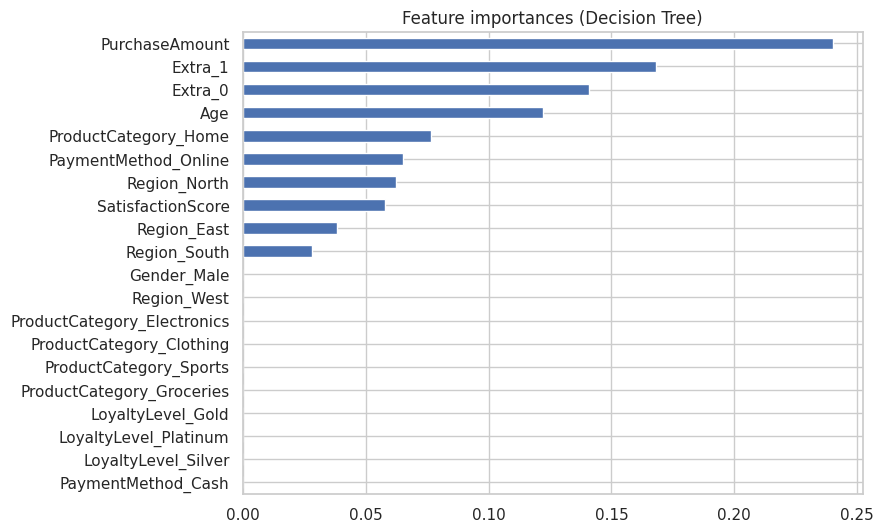


Вычисляю permutation importance (может занять некоторое время)...


,0
Extra_1,0.004067
Region_East,0.002153
PurchaseAmount,0.000957
Age,0.000000
ProductCategory_Groceries,0.000000
Extra_0,0.000000
Gender_Male,0.000000
Region_North,0.000000
Region_South,0.000000
Region_West,0.000000


Fitting 5 folds for each of 40 candidates, totalling 200 fits

GridSearch Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2}
Best CV ROC AUC: 0.5288159901099448
Test ROC AUC (best tree): 0.41837550901687026
Test Accuracy (best tree): 0.9114832535885168


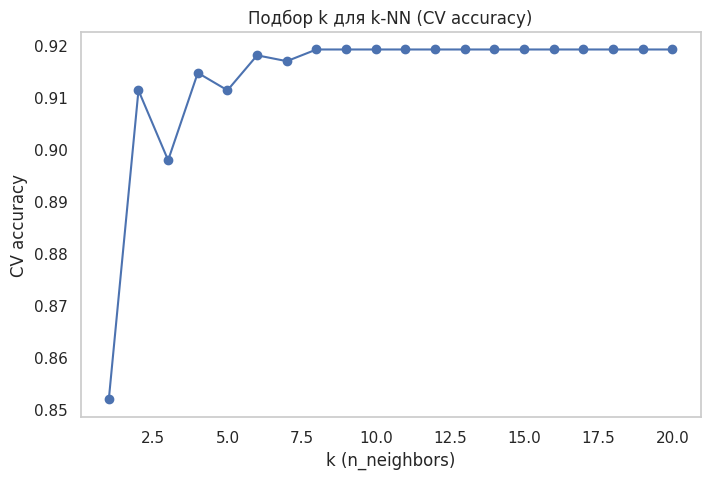

Best k (by CV accuracy): 8

--- k-NN metrics on test ---
k-NN test accuracy: 0.9138755980861244
k-NN ROC AUC: 0.5078897614892379
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       382
           1       0.00      0.00      0.00        36

    accuracy                           0.91       418
   macro avg       0.46      0.50      0.48       418
weighted avg       0.84      0.91      0.87       418



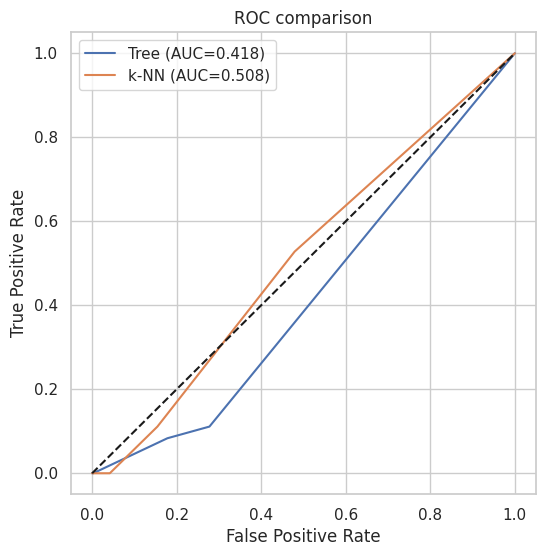


Готово. Скрипт выполнил полный pipeline: EDA, предобработка, Decision Tree (baseline + GridSearch), k-NN (подбор k), визуализации и оценки метрик.


In [116]:
# Colab-ready script для работы с вашими локально загруженными датасетами (в /content)
# Предполагается, что вы уже загрузили файлы store_train.csv и store_test.csv в Google Colab.
# Если у вас другие имена файлов — замените значения переменных train_path / test_path ниже.

# 0) ОПЦИОНАЛЬНО: установка дополнительных пакетов (раскомментируйте, если нужно)
# !apt-get install -y graphviz
# !pip install graphviz pydotplus shap --quiet

# 1) Импорты
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
# В Colab для отрисовки:
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

# 2) Путь к вашим файлам в Colab (замените, если имена или пути другие)
train_path = '/content/store_train.csv'
test_path  = '/content/store_test.csv'

# 3) Загрузка файлов (локально, из /content)
try:
    train = pd.read_csv(train_path)
    test  = pd.read_csv(test_path)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Не найден(ы) файл(ы). Убедитесь, что файлы загружены в Colab и пути верны.\n"
        f"Ожидаемые пути: {train_path}, {test_path}"
    )

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
display(train.head())
display(test.head())

# 4) Быстрая проверка типов и пропусков
print("\n--- dtypes и пропуски в train ---")
display(train.dtypes)
display(train.isnull().sum().sort_values(ascending=False).head(20))

# 5) Целевая переменная: 'Returned' (0/1) — как в примере
target = 'Returned'
if target not in train.columns:
    raise ValueError(f"В train отсутствует столбец '{target}'. Проверьте файл.")

# 6) Простая предобработка
# - удаляем CustomerID (если есть)
drop_cols = [c for c in ['CustomerID'] if c in train.columns]
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# определим категориальные и числовые признаки (базово)
categorical = [c for c in ['Gender', 'Region', 'ProductCategory', 'LoyaltyLevel', 'PaymentMethod'] if c in train.columns]
numerical = [c for c in train.columns if c not in categorical + [target]]

print("Categorical:", categorical)
print("Numerical:", numerical)

# 7) Объединяем train+test для одинаковой one-hot обработки
train['_is_train'] = 1
test['_is_train'] = 0
df_all = pd.concat([train, test], axis=0, sort=False).reset_index(drop=True)

# one-hot кодирование категориальных признаков
df_all = pd.get_dummies(df_all, columns=categorical, drop_first=True)

# заполнение возможных NaN (медианой для чисел)
for col in df_all.columns:
    if df_all[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df_all[col]):
            df_all[col] = df_all[col].fillna(df_all[col].median())
        else:
            df_all[col] = df_all[col].fillna('NA')

# разделяем обратно
train_proc = df_all[df_all['_is_train']==1].drop(columns=['_is_train']).reset_index(drop=True)
test_proc  = df_all[df_all['_is_train']==0].drop(columns=['_is_train']).reset_index(drop=True)

# 8) Формируем X, y
X_train = train_proc.drop(columns=[target])
y_train = train_proc[target].astype(int)

X_test = test_proc.drop(columns=[target])
y_test = test_proc[target].astype(int)

print("\nProcessed shapes:", X_train.shape, X_test.shape)

# 9) Краткая EDA: распределение target
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title('Распределение Returned (train)')
plt.show()

# 10) Обучение простого дерева решений (baseline)
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=17)
clf_tree.fit(X_train, y_train)

# 11) Оценка на тестовой выборке
y_pred = clf_tree.predict(X_test)
y_proba = clf_tree.predict_proba(X_test)[:,1]

print("\n--- Decision Tree (baseline) metrics on test ---")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred, zero_division=0))
try:
    print("ROC AUC:  ", roc_auc_score(y_test, y_proba))
except Exception:
    print("ROC AUC:  Невозможно (возможно один класс в y_test)")

print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix (Decision Tree)')
plt.show()

# 12) Визуализация дерева (простая)
plt.figure(figsize=(18,8))
plot_tree(clf_tree, feature_names=X_train.columns, class_names=['0','1'], filled=True, rounded=True, fontsize=8)
plt.show()

# 13) Важность признаков
feat_imp = pd.Series(clf_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importances (Decision Tree):")
display(feat_imp.head(20))
plt.figure(figsize=(8,6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature importances (Decision Tree)')
plt.show()

# 14) Permutation importance (robustная оценка)
print("\nВычисляю permutation importance (может занять некоторое время)...")
r = permutation_importance(clf_tree, X_test, y_test, n_repeats=10, random_state=0, n_jobs=2)
perm_imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
display(perm_imp.head(20))

# 15) GridSearch для дерева (подбор гиперпараметров)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,9, None],
    'min_samples_leaf': [1,2,5,10]
}
gs = GridSearchCV(DecisionTreeClassifier(random_state=17), param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
print("\nGridSearch Best params:", gs.best_params_)
print("Best CV ROC AUC:", gs.best_score_)

best_tree = gs.best_estimator_
y_pred_best = best_tree.predict(X_test)
y_proba_best = best_tree.predict_proba(X_test)[:,1]
print("Test ROC AUC (best tree):", roc_auc_score(y_test, y_proba_best))
print("Test Accuracy (best tree):", accuracy_score(y_test, y_pred_best))

# 16) k-NN (требует масштабирования)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Подбор k через cross-val (простая проверка)
neighbors = list(range(1,21))
scores = []
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    cv_score = np.mean(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1))
    scores.append(cv_score)

plt.figure(figsize=(8,5))
plt.plot(neighbors, scores, marker='o')
plt.xlabel('k (n_neighbors)')
plt.ylabel('CV accuracy')
plt.title('Подбор k для k-NN (CV accuracy)')
plt.grid()
plt.show()

best_k = neighbors[int(np.argmax(scores))]
print("Best k (by CV accuracy):", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_knn_pred = knn.predict(X_test_scaled)
y_knn_proba = knn.predict_proba(X_test_scaled)[:,1]

print("\n--- k-NN metrics on test ---")
print("k-NN test accuracy:", accuracy_score(y_test, y_knn_pred))
try:
    print("k-NN ROC AUC:", roc_auc_score(y_test, y_knn_proba))
except Exception:
    print("k-NN ROC AUC: Невозможно (возможно один класс в y_test)")
print(classification_report(y_test, y_knn_pred, zero_division=0))

# 17) ROC-кривые для сравнения (если возможно)
try:
    fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_best)
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_proba)
    plt.figure(figsize=(6,6))
    plt.plot(fpr_t, tpr_t, label=f'Tree (AUC={roc_auc_score(y_test,y_proba_best):.3f})')
    plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC={roc_auc_score(y_test,y_knn_proba):.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC comparison')
    plt.legend()
    plt.show()
except Exception:
    print("Не удалось построить ROC (возможно в y_test отсутствует положительный или отрицательный класс)")

# 18) Сохранение моделей (опционально)
# import joblib
# joblib.dump(best_tree, '/content/best_tree_store.joblib')
# joblib.dump(scaler, '/content/scaler_store.joblib')

print("\nГотово. Скрипт выполнил полный pipeline: EDA, предобработка, Decision Tree (baseline + GridSearch), k-NN (подбор k), визуализации и оценки метрик.")